In [32]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Project Plan: Quantitative Analysis of Swedish Spot Prices (SE3 & SE4)

## Objective
Analyze electricity spot prices in Sweden's high-demand areas SE3 and SE4 to:

- Explore trends, volatility, and seasonality.
- Identify high-price regimes using probabilistic models.
- Model extreme price events with Extreme Value Theory (EVT).
- Construct a sustainability-informed portfolio signal for green energy allocation.

---

## Step 1: Data Loading & Cleaning
- Load `Elspotprices2015-2024.csv` with correct decimal formatting.  
- Convert `HourDK` to datetime and set as index.  
- Filter only **SE3 and SE4** zones.  
- Pivot so each zone is a column.  
- Handle missing values via interpolation.  
- Save cleaned dataset for analysis.

---

## Step 2: Exploratory Data Analysis (EDA)
- Plot SE3 and SE4 spot prices over time.  
- Calculate rolling mean and standard deviation for volatility.  
- Examine seasonality: daily, weekly, monthly patterns.  
- Compare correlations between SE3 and SE4.

---

## Step 3: Probabilistic High-Price Regimes
- Fit **Hidden Markov Models (HMM)** to detect high-price vs low-price periods.  
- Visualize regimes on price plots.  
- Analyze regime statistics: mean, volatility, duration.

---

## Step 4: Extreme Price Modeling
- Identify extreme price events in SE3 and SE4.  
- Fit a **generalized extreme value (GEV) distribution**.  
- Calculate probabilities of extreme spikes per zone.

---

## Step 5: Sustainability Signal
- Low price → likely high renewable production.  
- Construct a **quantile-based sustainability signal** per zone.  
- Optionally combine SE3 and SE4 signals into a portfolio allocation.

---

## Step 6: Visualization & Reporting
- Plot trends, regimes, EVT probabilities, and sustainability signals.  
- Optional: create a dashboard (Power BI / matplotlib / Plotly).  
- Summarize insights for CV and interview presentation.

---

## Optional Extensions
- Correlate spot prices with **wind and solar generation**.  
- Forecast prices using **ARIMA or LSTM models**.  
- Backtest a simple **portfolio allocation** using the sustainability signal.  


In [20]:
df = pd.read_csv("Elspotprices2015-2024.csv", sep=';', decimal=',')

df['HourDK'] = pd.to_datetime(df['HourDK'])  # default format, no dayfirst
df.set_index('HourDK', inplace=True)



In [ ]:

df = df.dropna(subset=['PriceArea','SpotPriceEUR'])
sweden_areas = ['SE1', 'SE2', 'SE3', 'SE4']
df_sweden = df[df['PriceArea'].isin(sweden_areas)].copy()
# Check all unique PriceArea values
print(df['PriceArea'].unique())

# Count non-missing per zone
print(df.groupby('PriceArea')['SpotPriceEUR'].count())


# Pivot so each zone is a column
df_sweden = df_sweden.pivot_table(index=df_sweden.index, 
                                  columns='PriceArea', 
                                  values='SpotPriceEUR')

# Interpolate missing values
df_sweden = df_sweden.interpolate(method='time')



['DK1' 'DK2' 'SE3' 'NO2' 'SYSTEM' 'SE4' 'DE' 'GB2' 'SYS' 'SE' 'KT']
PriceArea
DE        207518
DK1       216061
DK2       205070
GB2           24
KT         35924
NO2       216061
SE        100837
SE3       107928
SE4       107928
SYS       100837
SYSTEM    115224
Name: SpotPriceEUR, dtype: int64


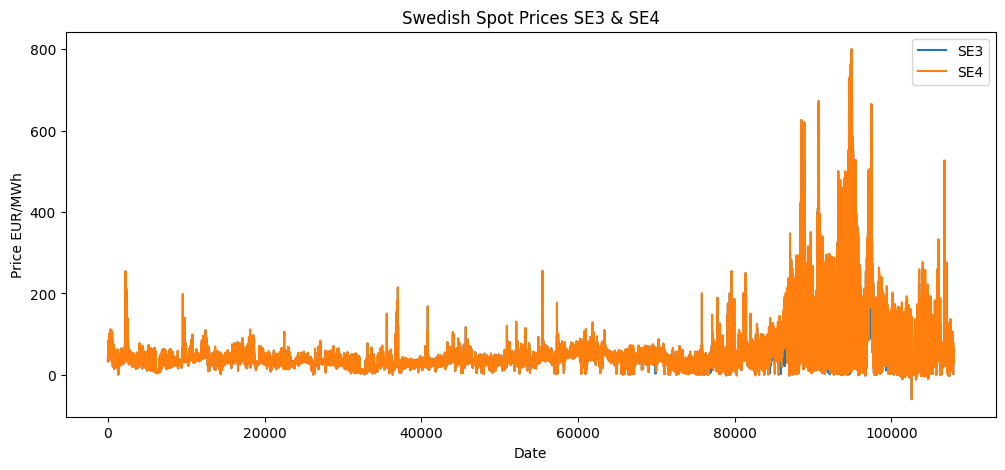

In [36]:
df=pd.read_csv("Sweden_Elspot_2015-2024.csv")

plt.figure(figsize=(12,5))
plt.plot(df.index, df_sweden['SE3'], label='SE3')
plt.plot(df.index, df_sweden['SE4'], label='SE4')

# Add title and labels
plt.title('Swedish Spot Prices SE3 & SE4')
plt.xlabel('Date')
plt.ylabel('Price EUR/MWh')

# Add legend
plt.legend()

# Show plot
plt.show()